<h2><strong>PROJECT TITLE</strong></h2>
Smart House Price Prediction Using Machine Learning and Ensemble Models

<h2><strong>NAME</strong></h2>
Shirley Mary

<h2><strong>CONTRIBUTION</strong></h2>
Solo project

<h2><strong>GitHub Repository</strong></h2>
https://github.com/Shirls-0913/house-price-prediction-ml-ensemble

<h2><strong> PROJECT INTRODUCTION</strong></h2>
This project, “House Price Prediction,” focuses on performing an end-to-end data analysis and developing robust machine learning models to predict house prices based on multiple property and market-related features. The study begins with a comprehensive exploratory data analysis (EDA) to understand the structure, distribution, and relationships within the dataset. Creative feature engineering techniques are applied to enhance the predictive power of the data by extracting meaningful insights from raw variables.

Advanced regression algorithms such as Random Forest Regression and Gradient Boosting Regression are implemented to build accurate and reliable prediction models. These models capture complex, non-linear relationships between house features and prices, enabling better performance compared to traditional regression approaches.

<h2><strong>PROJECT WORKFLOW</strong></h2>

### 1. Data Collection & Loading
- Load dataset using pandas (`pd.read_csv()`).
- Check structure using `head()`, `info()`, and `describe()`.

### 2. Data Cleaning & Preprocessing
- Handle missing values (drop or fill).
- Treat outliers using winsorization.
- Encode categorical variables if needed.
- Split data into features (X) and target (y).

### 3. Exploratory Data Analysis (EDA)
- Visualize data using matplotlib and seaborn.
- Analyze distributions and correlations.
- Identify important features affecting house prices.

### 4. Feature Scaling
- Apply StandardScaler to normalize numerical features.

### 5. Train-Test Split
- Split dataset into training and testing sets (e.g., 80/20).

### 6. Model Building
- Train models:
  - RandomForestRegressor
  - GradientBoostingRegressor

### 7. Hyperparameter Tuning
- Use RandomizedSearchCV for optimization.
- Apply cross-validation to improve performance.

### 8. Model Evaluation
- Evaluate using:
  - R² Score
  - Mean Squared Error (MSE)
- Validate with cross_val_score().

### 9. Model Comparison
- Compare model performances.
- Select the best model.

### 10. Final Prediction & Insights
- Predict house prices using the best model.
- Interpret key influencing factors.

### 11. Conclusion
- Summarize results and performance.
- Suggest future improvements.

<h2><strong>Importing Libraries</strong></h2>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")  # Visualization style

# Mathematical Utilities
import math

# Import winsorize function to cap extreme values (outliers) in numerical data
from scipy.stats.mstats import winsorize

# Train-test split
from sklearn.model_selection import train_test_split

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# ML models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# RandomizedSearchCV to perform hyperparameter tuning by searching over a randomized grid of parameters with cross-validation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# Evaluation mertrics
from sklearn.metrics import mean_squared_error, r2_score

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load data
data=pd.read_csv("house_price_prediction(p2).csv")

In [3]:
# Basic check
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
# Displays the data type of each column in the dataset(int, float, object)
data.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [8]:
# Shows the number of rows and columns in the dataset
data.shape

(1460, 81)

<h2><strong>Exploratory Data Analysis(EDA)</strong></h2>

In [9]:
# Basic dataset inspection:
# 1. Print data types of each column
# 2. Calculate and display the percentage of missing values per column
print("\nData Types:\n", data.dtypes)
print("\nMissing Values (%):\n", (data.isnull().sum()/len(data)*100).sort_values(ascending=False))


Data Types:
 Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

Missing Values (%):
 PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64


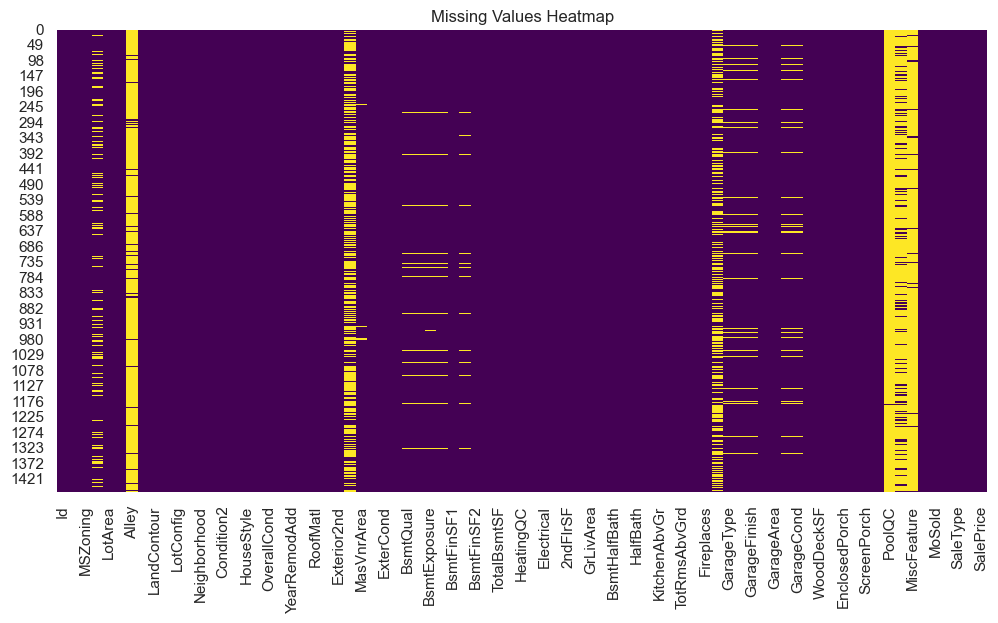

In [10]:
# Visualize missing values pattern:
# Heatmap showing the distribution of missing values across the dataset
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

The heatmap visualises the pattern of missingness across features.
Columns with dense yellow strips (e.g., Alley, PoolQC, MiscFeature) have many missing values, suggesting they may need imputation or removal.
Sparse yellow patterns indicate occasional missingness that might be handled case‑by‑case.
Understanding this helps decide data‑cleaning strategies (impute, drop columns/rows, or engineer features) before modeling.

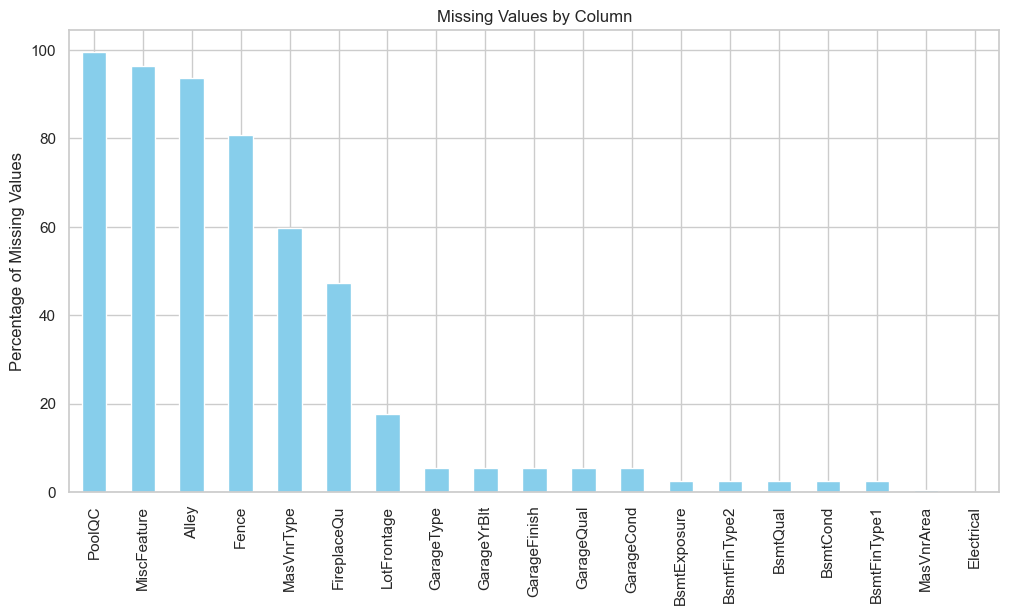

In [11]:
#  Missing values summary:
# Bar plot illustrating the percentage of missing values per column
missing_values = data.isnull().sum() / len(data) * 100
missing_values = missing_values[missing_values > 0]
plt.figure(figsize=(12,6))
missing_values.sort_values(ascending=False).plot.bar(color='skyblue')
plt.ylabel("Percentage of Missing Values")
plt.title("Missing Values by Column")
plt.show()

Drop the columns with >50% missing data (PoolQC, MiscFeature, Alley, Fence, MasVnrType) because they are unlikely to provide useful information.
For the remaining columns with smaller missing percentages (e.g. FireplaceQu, LotFrontage), impute values using appropriate methods.

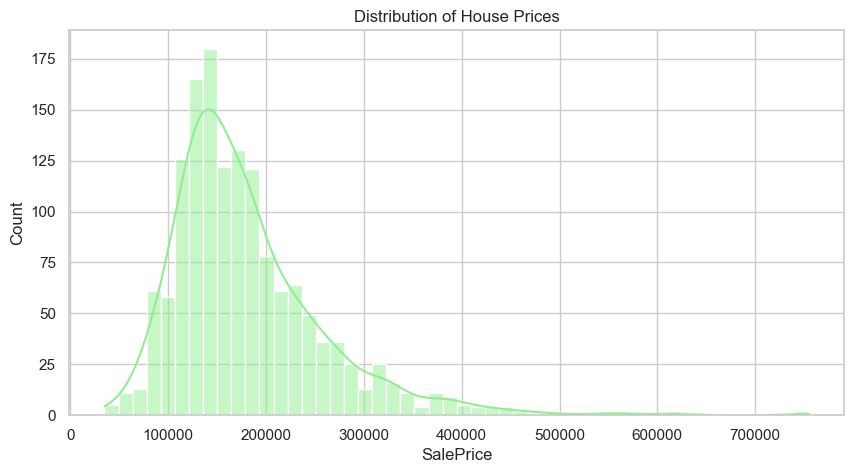

In [12]:
# Target variable analysis:
# Visualize the distribution of house prices to understand skewness and spread
plt.figure(figsize=(10,5))
sns.histplot(data['SalePrice'], bins=50, kde=True, color='lightgreen')
plt.title("Distribution of House Prices")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

The SalePrice distribution is right-skewed, meaning most prices are low with a few high-value outliers

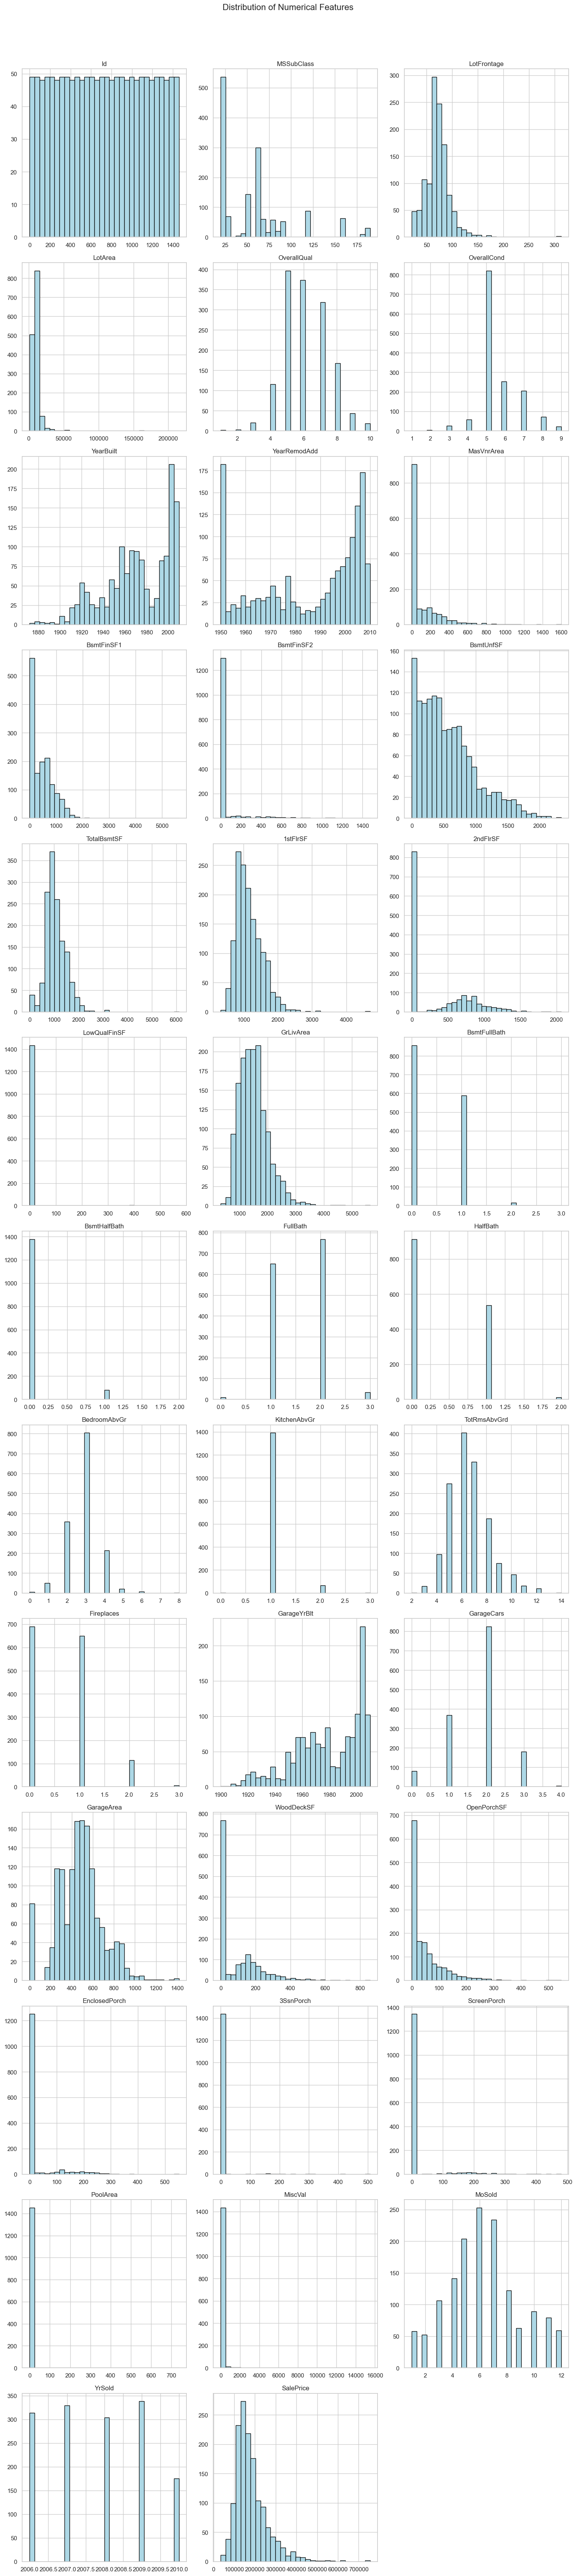

In [13]:
# Numerical feature analysis:
# Plot distributions of all numerical features to identify patterns and outliers
numerical_columns = data.select_dtypes(include=['int64','float64']).columns
cols = 3
rows = math.ceil(len(numerical_columns)/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    axes[i].hist(data[col], bins=30, color='lightblue', edgecolor='black')
    axes[i].set_title(col, fontsize=12)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Distribution of Numerical Features", fontsize=16, y=1.02)
plt.show()

The distributions of numerical features reveal several trends. Many features, such as SalePrice, LotFrontage, LotArea, GrLivArea, TotalBsmtSF, and house_age, are right-skewed, with a few extreme values. Most homes have moderate quality and condition (OverallQual, OverallCond) and 1–2 full baths, 1 kitchen, and 2 garage spaces. Features like MasVnrArea, BsmtFinSF1/2, and porch areas show many zeros, indicating optional features are absent in most houses. Seasonal trends are observed in sales (MoSold), and houses vary widely in total square footage (total_sqft) and lot size (LotArea). Overall, most homes cluster around average sizes and moderate quality, with a long tail for larger or higher-priced properties.

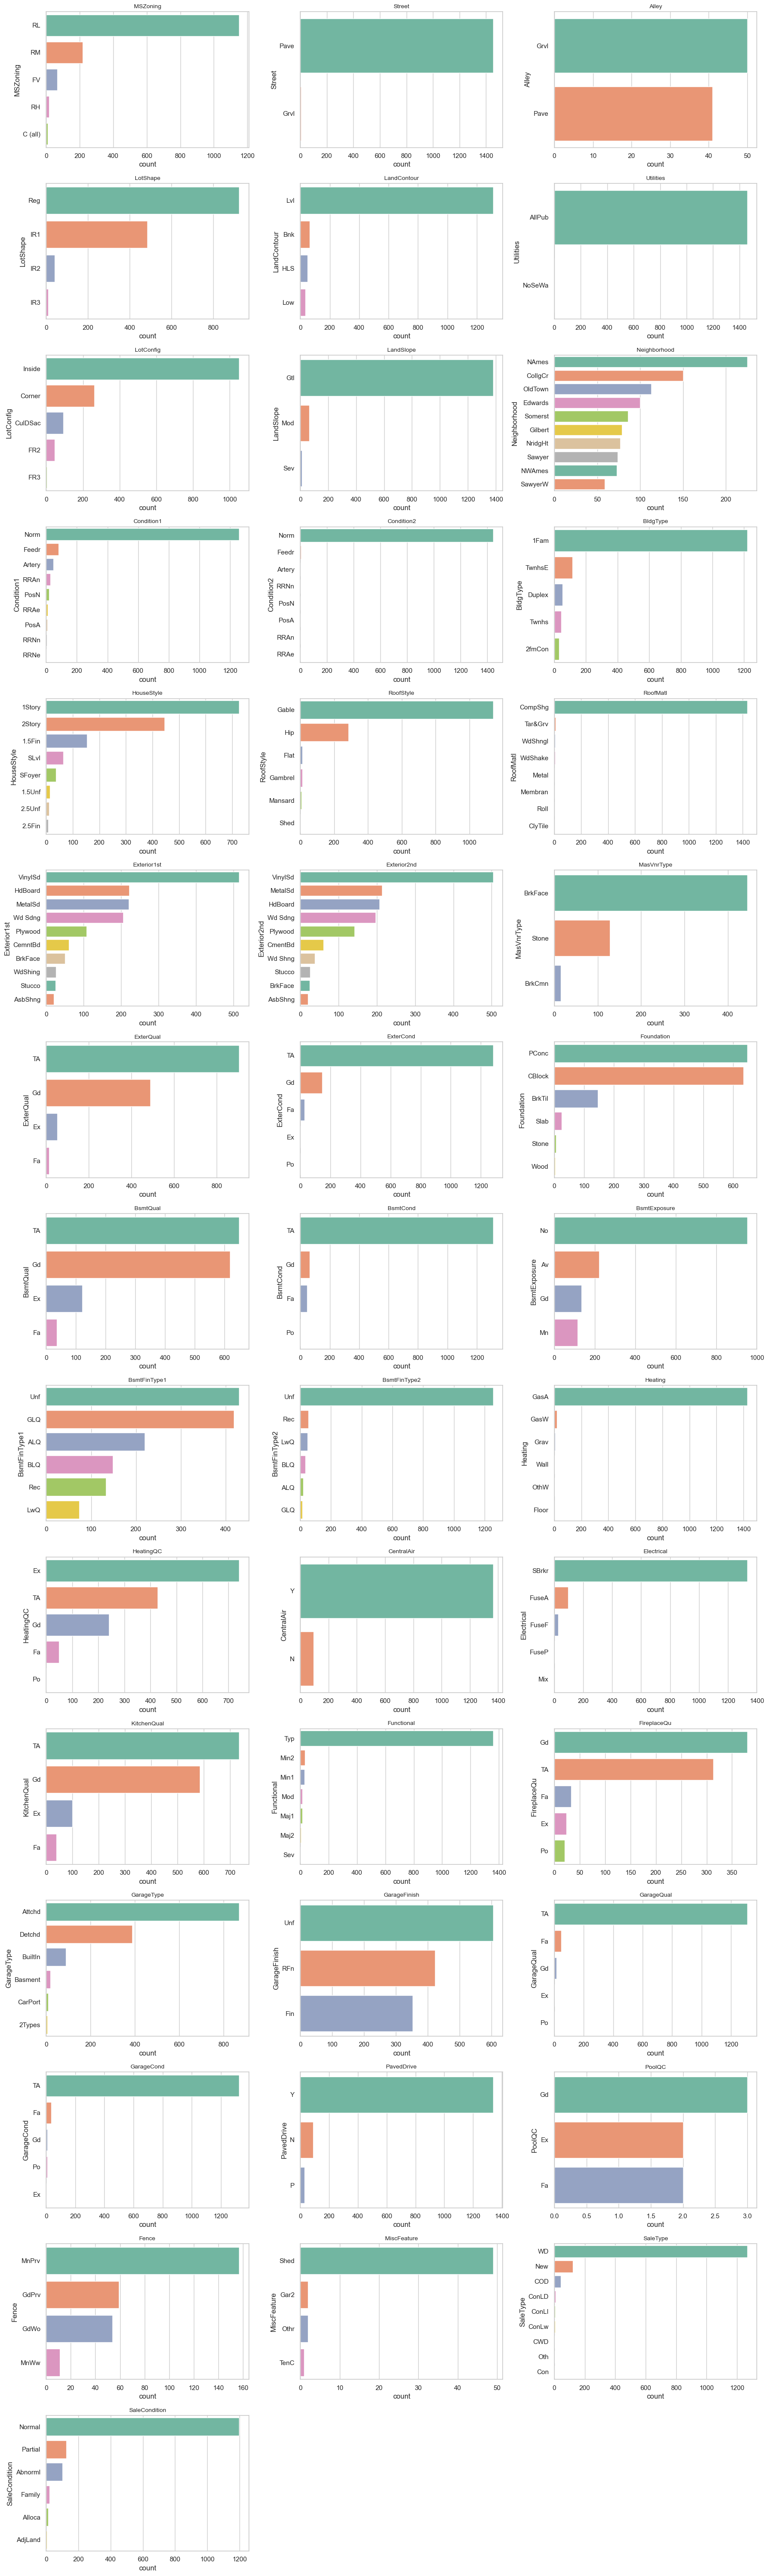

In [14]:
# Categorical feature analysis:
# Display category counts for each categorical variable
categorical_columns = data.select_dtypes(include=['object']).columns
n_cols = 3        # number of plots per row
top_n = 10        # show only top categories
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    order = data[col].value_counts().head(top_n).index
    sns.countplot(
        y=col,
        data=data,
        order=order,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The analysis of categorical features shows that most properties fall into a few dominant categories. For example, MSZoning is primarily “RL” (residential low density), road access is mostly via paved streets (Street = Pave) and alleys (Alley = Pave), lot shapes are generally regular (LotShape = Reg), and land is mostly level (LandContour = Lvl) with all utilities available (Utilities = AllPub). Building and exterior characteristics also show consistent patterns: BldgType = 1Fam, HouseStyle = 1Story, RoofStyle = Gable, RoofMatl = CompShg, and Exterior1st/2nd = VinylSd. Most sales occur under Normal conditions, while Partial or Abnormal sales are less frequent. Overall, the visualizations confirm that most observations cluster in dominant categories, providing a consistent and interpretable dataset for further analysis.

<h2><strong>Correlation with Target</strong></h2>

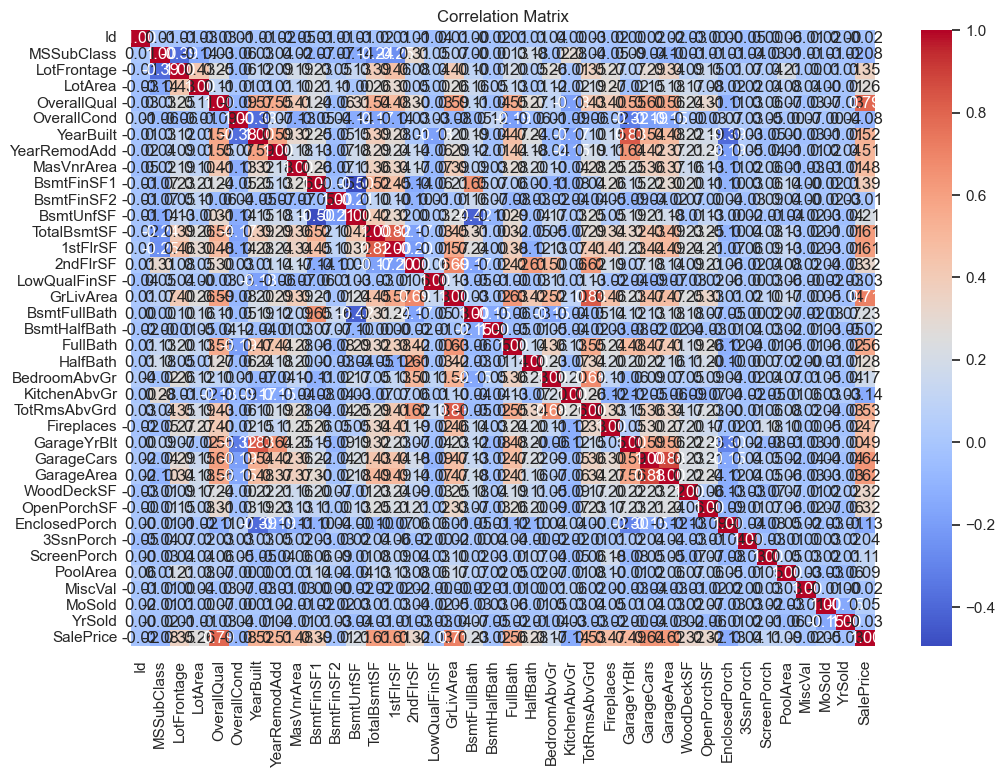

In [15]:
# Correlation matrix
corr_matrix = data[numerical_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The image shows a correlation matrix (heatmap) for a housing dataset.

- What it is: Each cell in the grid represents the correlation coefficient (r) between two variables (features) listed on the rows and columns.
- Color coding: Blue indicates a positive correlation (variables move together), red indicates a negative correlation (variables move in opposite directions). Intensity shows strength (darker = stronger).
- Diagonal: All values are 1.0 (perfect self‑correlation).
- Interpretation: Strong positive correlations (e.g., between “GrLivArea” and “SalePrice”) mean larger living area tends to raise the sale price. Strong negative correlations (e.g., “BsmtUnfSF” with some finished basement features) suggest unfinished basement space reduces related finished‑space values.

In [16]:
target = 'SalePrice'

corr_with_target = data[numerical_columns].corr()[target].sort_values(ascending=False)

print("Correlation with Target:\n", corr_with_target)

Correlation with Target:
 SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr

The strongest predictors of house price are OverallQual, GrLivArea, GarageCars, and GarageArea, indicating quality and size of the house drive most of the variation in sale price. Many other features have weak or negligible correlation, suggesting limited linear impact.

<h2><strong>Outlier Detection</strong></h2>

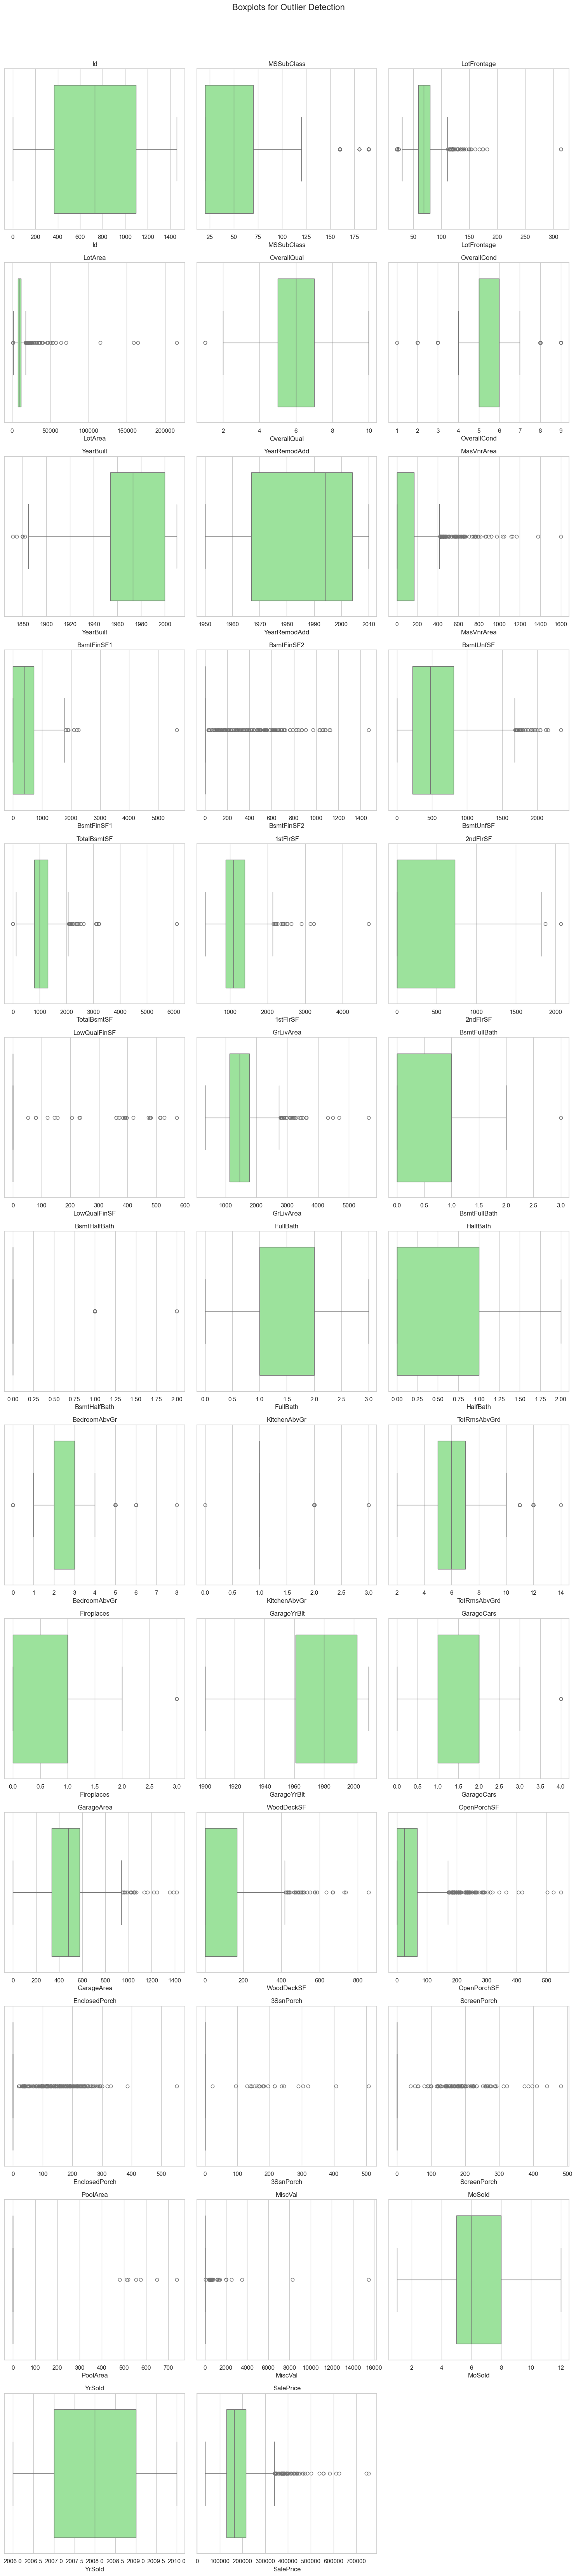

In [17]:
cols = 3
rows = math.ceil(len(numerical_columns) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=data[col], color='lightgreen', ax=axes[i])
    axes[i].set_title(col)

# Remove extra plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Boxplots for Outlier Detection", fontsize=16, y=1.02)
plt.show()

- Boxplots visually show the distribution of each numerical feature.

- They highlight outliers, median, and interquartile range (IQR).

- Useful for detecting extreme values that may need handling (like winsorization or transformation).

A grid of boxplots, one for each numerical feature.

Each boxplot shows:

Box → 25th to 75th percentile (IQR)

Line inside box → median

Whiskers → approximate range of typical values

Points outside whiskers → outliers

Example: GrLivArea boxplot might show a few points far above the whiskers → potential extreme values.

<h2><strong>Data Cleaning</strong></h2>

In [18]:
# Impute missing numerical values with median
for col in numerical_columns:
    data[col].fillna(data[col].median(), inplace=True)

In [19]:
# Impute missing categorical values with mode
for col in categorical_columns:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [20]:
# Check duplicates
duplicate_count = data.duplicated().sum()
print("\nTotal Duplicate Rows:", duplicate_count)


Total Duplicate Rows: 0


<h2><strong>Feature Engineering</strong></h2>

In [21]:
# 1. Feature engineering(Creative)
data['house_age'] = 2026 - data['YearBuilt']

data['total_bathrooms'] = (
    data['FullBath'] +
    0.5 * data['HalfBath'] +
    data['BsmtFullBath'] +
    0.5 * data['BsmtHalfBath']
)

data['total_sqft'] = data['GrLivArea'] + data['TotalBsmtSF']

data['lot_size_category'] = pd.cut(
    data['LotArea'],
    bins=[0, 1000, 2000, 5000, 10000, data['LotArea'].max()],
    labels=['very_small', 'small', 'medium', 'large', 'very_large']
)
# 2. Handle missing values
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns

data[num_cols] = data[num_cols].fillna(0)
data[cat_cols] = data[cat_cols].astype('object').fillna('None')

<h2><strong>Outlier Handling</strong></h2>

In [22]:
data_winsorized = data.copy()

for col in numerical_columns:
    data_winsorized[col] = winsorize(data_winsorized[col], limits=[0.05, 0.05])

<h2><strong>Dataset Split</strong></h2>

In [23]:
# split target
y = data['SalePrice']
X = data.drop('SalePrice', axis=1)

# Train / Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encode (NO leakage)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

<h2><strong>Model Training & Evaluation</strong></h2>

In [24]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("Gradient Boosting R2 Score:", r2_score(y_test, y_pred_gb))

Random Forest RMSE: 31771.42723267939
Random Forest R2 Score: 0.8683988710342452
Gradient Boosting RMSE: 33116.3971439348
Gradient Boosting R2 Score: 0.8570209753573186


In [25]:
# "Random Forest is more accurate overall based on both metrics (lower RMSE + higher R²)."
# "Therefore, Random Forest was selected as the final model, and further interpretation was done using feature importance.”

<h2><strong>Randomized Search</strong></h2>

In [26]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': None, 'max_depth': None}


This model uses 100 decision trees, allowing it to learn patterns effectively while maintaining reasonable computation time. With no limit on tree depth and a minimum split size of 2, the trees grow very deep and capture detailed patterns in the data. Since all features are considered at each split, the model can make more informed decisions, but it may reduce randomness. Overall, this setup aims for high accuracy but may increase the risk of overfitting.

<h2><strong>Cross Validation</strong></h2>

In [27]:
cv_scores = cross_val_score(
    RandomForestRegressor(**rf_random.best_params_, random_state=42),
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-validation R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

Cross-validation R2 scores: [0.8926076  0.76586882 0.82284755 0.88734395 0.86256409]
Mean CV R2: 0.8462464029744174


The cross-validation R² scores show that the model performs well across different data splits, with values ranging from about 0.77 to 0.89. The mean R² of 0.846 indicates that, on average, the model explains around 84.6% of the variance in the data. While there is some variation between folds, the overall performance is strong and suggests the model generalizes reasonably well

<h2><strong>Feature Importance(Random Forest)</strong></h2>

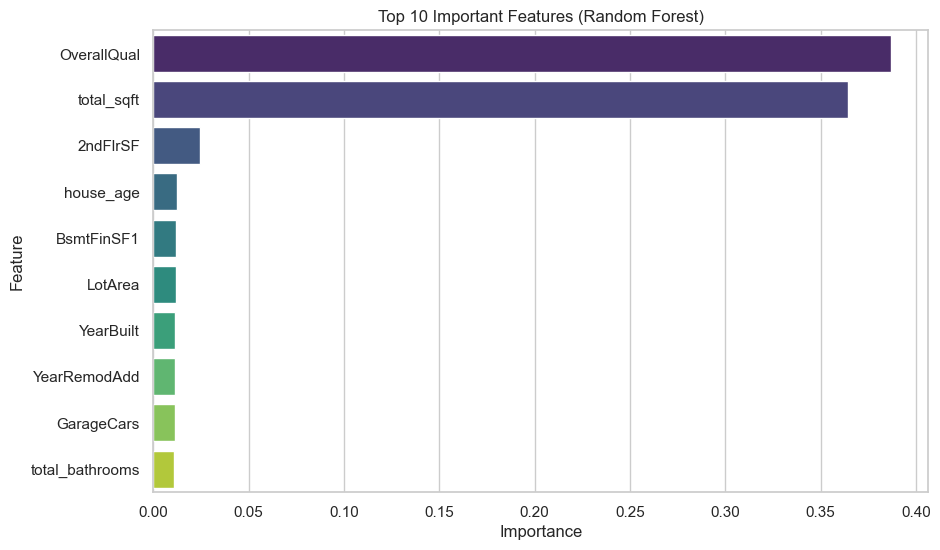

In [28]:
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

The chart shows the Top 10 Important Features from a Random Forest model, ranking variables by their importance (horizontal axis) in predicting a target outcome. The features are listed on the vertical axis and include:

1. OverallQual – the most influential feature, with importance ≈ 0.35.
2. total_sqft – second most important, ≈ 0.15.
3. 2ndFlrSF, house_age, BsmtFinSF1, LotArea, YearBuilt, YearRemodAdd, GarageCars, and total_bathrooms follow with progressively lower importance values.

In short, overall quality and total square footage are the dominant predictors in this model.

<h2><strong>Model Comparison Report</strong></h2>

Models Evaluated:

Two machine learning models were implemented and evaluated for house price prediction:
1.Random Forest Regressor
2.Gradient Boosting Regressor.
Both models were trained on the same dataset using identical preprocessing and feature-engineered inputs to ensure a fair comparison.


Analysis:

The Random Forest model achieved a lower RMSE, indicating smaller prediction errors compared to Gradient Boosting.
The higher R² score of Random Forest shows that it explains a greater proportion of variance in house prices.
Although Gradient Boosting performed competitively, its overall accuracy was slightly lower across both evaluation metrics.


Model Selection:

Based on the comparison results, Random Forest was selected as the final model due to its superior predictive performance and stability.
Subsequent analysis, including feature importance and model interpretation, was therefore conducted using the Random Forest model.


Conclusion of Model Comparison:

The comparison demonstrates that while both models are effective for house price prediction, Random Forest provides better accuracy and reliability, making it the most suitable choice for this project.

<h2><strong>Customer House-Buying Suggestions</strong></h2>

Budget & Price: Recommend homes within the customer’s budget, prioritizing good value based on predicted price.

Location: Suggest neighborhoods (Neighborhood) with desired amenities, safety, and potential property appreciation.

House Age: Consider house_age — newer homes for low maintenance, older homes if willing to renovate.

Bathrooms: Use total_bathrooms to match family size and needs.

Living Space: Recommend homes with larger total_sqft for comfort and functionality.

Lot Size: Choose homes based on lot_size_category to match outdoor space preference.

Key Features: Factor in garages, porches, pools, and other amenities for lifestyle fit.

Balanced Choice: Suggest houses that optimize price, area, features, and overall value.

<h2><strong>Conclusion</strong></h2>

In this project, house prices were predicted using two ensemble regression models: Random Forest and Gradient Boosting. The data was carefully preprocessed, including handling missing values, creating domain-specific engineered features such as total_sqft and total_bathrooms, and managing outliers through winsorization. Both models were trained on the same feature-engineered dataset to ensure a fair comparison.

Random Forest emerged as the best-performing model, achieving the lowest RMSE and highest R² on the test set, demonstrating both accuracy and stability in predictions. Feature importance analysis highlighted that engineered variables like total_sqft and total_bathrooms were key drivers of model performance, confirming the effectiveness of the feature engineering process. Gradient Boosting also performed competitively but showed slightly lower predictive accuracy compared to Random Forest.

Overall, the project demonstrates that careful preprocessing, thoughtful feature engineering, and robust ensemble modeling can produce reliable and interpretable predictions for house prices, providing actionable insights for practical decision-making.